# Notebook 02: T cell subset analysis

Analysis of T cell subpopulations identified in Notebook 01 using the annotated PBMC dataset (GSE120221, donor A). Focuses:
- Differential expression across CellTypist-annotated T cell subtypes
- Gene signature scoring for naive, cytotoxic, and exhaustion states

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.figdir = '../results/'
sc.settings.verbosity = 1

adata = sc.read_h5ad('../data/adata_annotated.h5ad')
print(adata)
adata.obs['cell_type_coarse'].value_counts()

/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead

AnnData object with n_obs × n_vars = 2989 × 17213
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_0.50', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'cell_type_coarse', 'cell_type_fine'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_labe

cell_type_coarse
T cells           1041
Erythroid          696
Monocytes          518
HSC/MPP            349
DC                 103
B-cell lineage      95
pDC                 52
B cells             47
ILC                 41
Plasma cells        39
Fibroblasts          8
Name: count, dtype: int64

In [2]:
adata_t = adata[adata.obs['cell_type_coarse'] == 'T cells'].copy()
print(adata_t)
adata_t.obs['cell_type_fine'].value_counts()

AnnData object with n_obs × n_vars = 1041 × 17213
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_0.50', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'cell_type_coarse', 'cell_type_fine'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_labe

cell_type_fine
Tcm/Naive helper T cells       408
Tem/Trm cytotoxic T cells      257
Tem/Effector helper T cells    196
Tcm/Naive cytotoxic T cells     98
Tem/Temra cytotoxic T cells     49
MAIT cells                      33
Name: count, dtype: int64

## 2. Re-embed T cell subset

Recompute neighbors and UMAP within the T cell subset only. The embeddings from Notebook 01 reflect the full PBMC landscape, recomputing here resolves finer structure within T cells.

/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():
/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


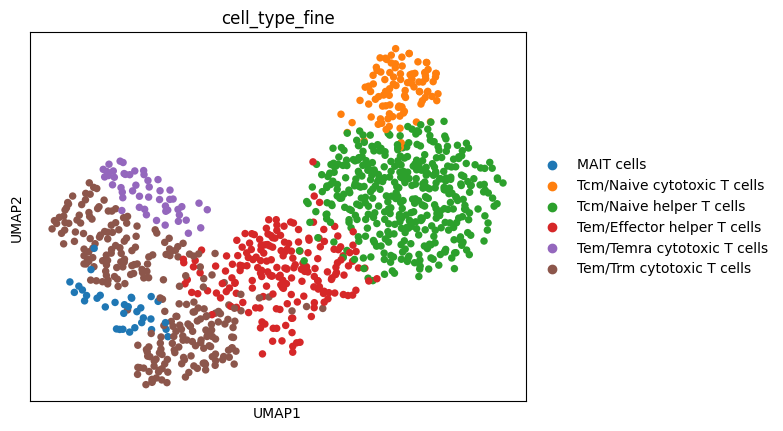

In [3]:
sc.pp.neighbors(adata_t, use_rep='X_pca')
sc.tl.umap(adata_t)
sc.pl.umap(adata_t, color='cell_type_fine', save='_tcell_subtypes.png')

Relatively clean separation between cell types. Cytotoxic populations (brown, purple, blue) cluster together and naive/helper populations (green, orange) cluster together.

## 3. Differential expression between T cell subtypes

Wilcoxon rank-sum test comparing each CellTypist fine-label subtype against all others. Six subtypes identified above.

Expected results:
- naive and cytotoxic clusters should look different from each other
- cytotoxic markers (GZMB, NKG7, PRF1) high in Tem/Trm and Tem/Temra cytotoxic rows
- naive/memory markers (CCR7, SELL, TCF7) high in Tcm/Naive rows

/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


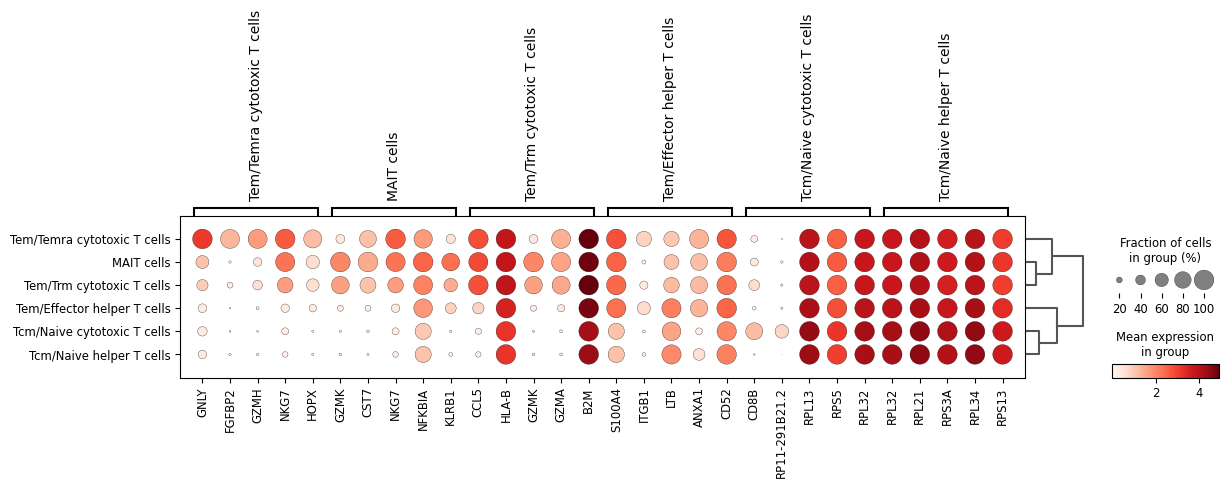

In [9]:
sc.tl.rank_genes_groups(adata_t, groupby='cell_type_fine', method='wilcoxon', use_raw=True)
sc.pl.rank_genes_groups_dotplot(adata_t, n_genes=5, save='_tcell_markers.png')

Results confirm expected transcriptional separation between subtypes:
- Cytotoxic markers (GNLY, GZMH, NKG7, GZMK) strongly enriched in Tem/Temra and Tem/Trm cytotoxic rows.
- Naive/central memory cells show an absence of strong discriminating markers.
- LTB and CD8B show modest enrichment in Tcm/Naive cytotoxic T cells, consistent with resting CD8+ identity.
- MAIT cells show a cytotoxic-like marker profile, consistent withtheir innate-like effector function.
- Ribosomal genes (RPL/RPS) are highly expressed across all subtypes, reflect housekeeping transcription.

## 4. Gene signature scoring

Score each cell for three functional gene signatures using `sc.tl.score_genes` (mean expression of signature genes minus a random background gene set of equal size):

- Cytotoxicity
- ExhaustionPDCD1
- Naive/memory

Scores overlaid on the T cell UMAP to visualize functional state distribution across subtypes.

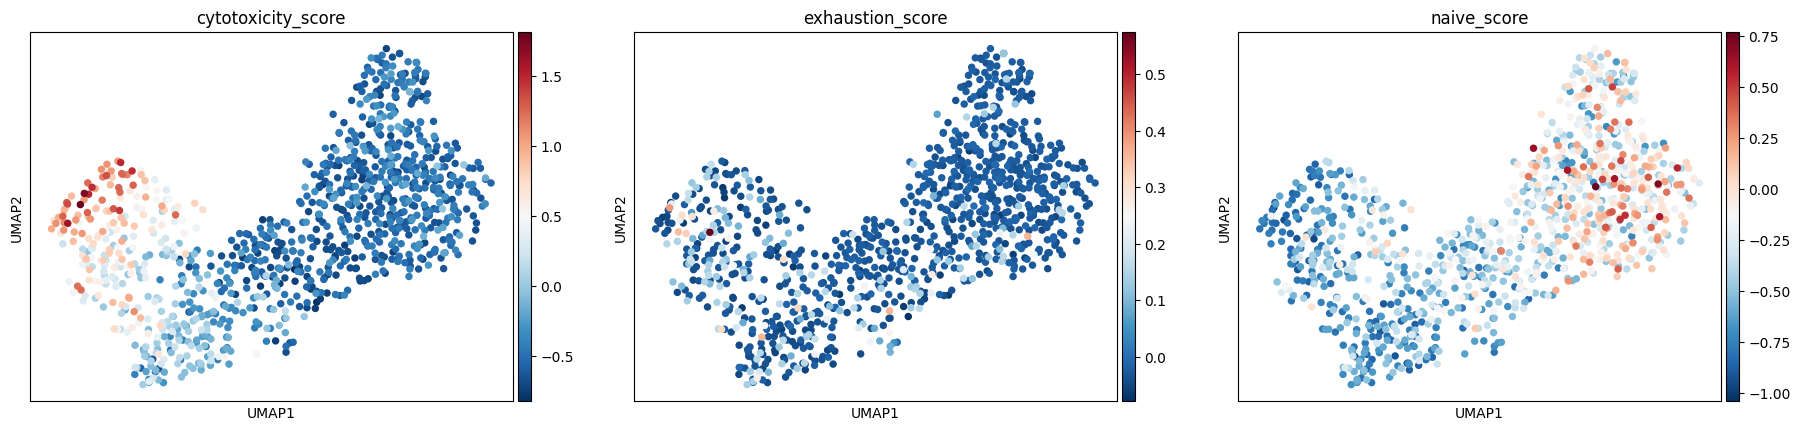

In [5]:
cytotoxicity_genes = ['GZMB', 'GZMK', 'PRF1', 'NKG7', 'GNLY']
exhaustion_genes = ['PDCD1', 'LAG3', 'HAVCR2', 'CTLA4', 'TIGIT']
naive_genes = ['CCR7', 'SELL', 'TCF7', 'LEF1']

sc.tl.score_genes(adata_t, cytotoxicity_genes, score_name='cytotoxicity_score')
sc.tl.score_genes(adata_t, exhaustion_genes, score_name='exhaustion_score')
sc.tl.score_genes(adata_t, naive_genes, score_name='naive_score')

sc.pl.umap(adata_t, color=['cytotoxicity_score', 'exhaustion_score', 'naive_score'],
           color_map='RdBu_r', ncols=3, save='_tcell_scores.png')

Results:
-  Cytotoxicity score: high scores concentrate in Tem/Trm and Tem/Temra clusters, confirming effector identity
- Naive score: high scores concentrate in Tcm/Naive helper and Tcm/Naive cytotoxic clusters, confirming resting cell identity
- Exhaustion score: weak and diffuse across all subtypes, consistent with healthy donor PBMCs where exhaustion markers are low. Exhaustion develops under chronic antigen stimulation (cancer, chronic infection) so not expected here.

## 5. Conclusion

Subsetting and re-embedding 1,041 T cells from the GSE120221 PBMC dataset resolved 6 transcriptionally distinct subtypes, consistent with CellTypist annotation from Notebook 01:

- Cytotoxic effector populations (Tem/Trm, Tem/Temra, MAIT) are clearly separated from naive/helper populations in UMAP space and show strong enrichment of cytotoxic markers (GNLY, GZMH, NKG7, GZMK)
- Naive/central memory populations show an absence of strong effector markers, consistent with their resting transcriptional state
- Gene signature scoring validates subtype identity: cytotoxicity and naive scores concentrate in their expected UMAP regions
- Exhaustion signature is low across all subtypes, consistent with healthy donor PBMCs

Notebook 03 will extend this analysis with trajectory inference (PAGA/diffusion pseudotime) to model the naive → effector/cytotoxic differentiation axis across these subtypes.